<div class="usecase-title">Crack Segmentation Benchmark on SDNET2018</div>

<div class="usecase-authors"><b>Authored by: </b>Kavita</div>

<div class="usecase-duration"><b>Duration:</b> 360 minutes</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, PyTorch, computer vision, Jupyter notebooks</div>
</div>

<div class="usecase-section-header">Scenario</div>

A data scientist needs to benchmark crack detection workflows on SDNET2018, but the available data may arrive either as paired image-mask segmentation splits or as raw image folders only. They want one notebook that can detect the supported layout, choose the right task, and produce reproducible benchmark results without manual restructuring.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will:
- detect whether SDNET2018 is available as paired segmentation data or raw image folders
- run a segmentation benchmark when masks are present and a classification fallback when they are not
- compare model performance with shared metrics, saved summaries, and reproducible outputs
- document the data-access assumptions needed to run the notebook from an API v2.1 mount

<div class="usecase-section-header">Background</div>

SDNET2018 is a common concrete crack dataset, but projects do not always arrive in the same structure. Some runs provide paired images and masks for segmentation, while others provide only raw surface folders for classification. This notebook keeps the workflow flexible by detecting the available layout, using API v2.1 dataset mounts when they are present, and benchmarking the most appropriate crack-detection task without forcing the data into a single format.

<div class="usecase-section-header">References</div>

- SDNET2018 crack dataset, accessed through the API v2.1 dataset mount used by this workspace
- `segmentation-models-pytorch`: https://github.com/qubvel/segmentation_models.pytorch
- `albumentations`: https://albumentations.ai/

In [1]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    import segmentation_models_pytorch as smp
except ImportError:
    smp = None

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('once', category=UserWarning)

def print_package_versions() -> pd.DataFrame:
    version_rows = [
        ('python', os.sys.version.split()[0]),
        ('torch', torch.__version__),
        ('torchvision', torchvision.__version__),
        ('segmentation_models_pytorch', getattr(smp, '__version__', 'not-installed')),
        ('albumentations', A.__version__),
        ('opencv-python', cv2.__version__),
        ('numpy', np.__version__),
        ('pandas', pd.__version__),
        ('matplotlib', plt.matplotlib.__version__),
        ('scikit-learn', sklearn.__version__),
    ]
    versions = pd.DataFrame(version_rows, columns=['package', 'version'])
    display(versions)
    return versions

VERSIONS_DF = print_package_versions()


,package,version
0,python,3.13.11
1,torch,2.11.0+cu128
2,torchvision,0.26.0+cu128
3,segmentation_models_pytorch,0.5.0
4,albumentations,2.0.8
5,opencv-python,4.13.0
6,numpy,2.4.3
7,pandas,3.0.1
8,matplotlib,3.10.8
9,scikit-learn,1.8.0


## Config Block

All experiment settings live here so the benchmark can be repeated with consistent defaults.


In [2]:
@dataclass
class Config:
    dataset_root: str = os.environ.get('API_V21_DATASET_ROOT', './dataset')
    segmentation_root: str = os.environ.get('API_V21_SEGMENTATION_ROOT', './data/crack_segmentation')
    image_subdir: str = 'images'
    mask_subdir: str = 'masks'
    artifact_root: str = './artifacts'
    checkpoints_dir: str = './artifacts/checkpoints'
    plots_dir: str = './artifacts/plots'
    predictions_dir: str = './artifacts/predictions'
    metrics_dir: str = './artifacts/metrics'
    segmentation_input_height: int = 512
    segmentation_input_width: int = 512
    classification_input_height: int = 224
    classification_input_width: int = 224
    batch_size: int = 16
    num_workers: int = 0
    pin_memory: bool = True
    persistent_workers: bool = False
    epochs: int = 1
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    patience: int = 3
    seed: int = 42
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    threshold: float = 0.5
    USE_AMP: bool = True
    val_fraction: float = 0.1
    test_fraction: float = 0.1
    deterministic: bool = True
    segmentation_models: Tuple[Tuple[str, Dict[str, str]], ...] = (
        ('unet_resnet34', {'architecture': 'unet', 'encoder_name': 'resnet34'}),
        ('deeplabv3plus_resnet50', {'architecture': 'deeplabv3plus', 'encoder_name': 'resnet50'}),
    )
    classification_models: Tuple[Tuple[str, Dict[str, str]], ...] = (
        ('resnet18', {'architecture': 'resnet18'}),
        ('efficientnet_b0', {'architecture': 'efficientnet_b0'}),
    )
    max_visualizations_per_model: int = 8

CFG = Config()
print(json.dumps(asdict(CFG), indent=2))

{
  "dataset_root": "./dataset",
  "segmentation_root": "./data/crack_segmentation",
  "image_subdir": "images",
  "mask_subdir": "masks",
  "artifact_root": "./artifacts",
  "checkpoints_dir": "./artifacts/checkpoints",
  "plots_dir": "./artifacts/plots",
  "predictions_dir": "./artifacts/predictions",
  "metrics_dir": "./artifacts/metrics",
  "segmentation_input_height": 512,
  "segmentation_input_width": 512,
  "classification_input_height": 224,
  "classification_input_width": 224,
  "batch_size": 16,
  "num_workers": 0,
  "pin_memory": true,
  "persistent_workers": false,
  "epochs": 1,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "patience": 3,
  "seed": 42,
  "threshold": 0.5,
  "USE_AMP": true,
  "val_fraction": 0.1,
  "test_fraction": 0.1,
  "deterministic": true,
  "segmentation_models": [
    [
      "unet_resnet34",
      {
        "architecture": "unet",
        "encoder_name": "resnet34"
      }
    ],
    [
      "deeplabv3plus_resnet50",
      {
        "archi

## Reproducibility Setup

This cell fixes deterministic seeds and configures PyTorch for repeatable results.


In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = CFG.deterministic | False
    torch.backends.cudnn.benchmark = bool(torch.cuda.is_available() and not CFG.deterministic)
    try:
        torch.use_deterministic_algorithms(CFG.deterministic, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id: int) -> None:
    worker_seed = CFG.seed + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

seed_everything(CFG.seed | 42)
TORCH_GENERATOR = torch.Generator().manual_seed(CFG.seed)


## Dataset Detection And Integrity Checks

The notebook checks for a mask-based segmentation layout first. If that is not present, it looks for the raw SDNET2018 cracked and uncracked folders and prepares a classification benchmark instead.


In [4]:
VALID_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
VALID_MASK_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
SPLITS = ('train', 'val', 'test')
SDNET_LAYOUT = {'D': ('CD', 'UD'), 'P': ('CP', 'UP'), 'W': ('CW', 'UW')}
CRACKED_CLASSES = {'CD', 'CP', 'CW'}
UNCRACKED_CLASSES = {'UD', 'UP', 'UW'}

def list_supported_files(directory: Path, valid_extensions: set[str]) -> List[Path]:
    if not directory.exists():
        return []
    return sorted([path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in valid_extensions])

def load_image_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if image is None:
        raise ValueError(f'Unable to read image file: {path}')
    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def load_mask_binary(path: Path) -> np.ndarray:
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f'Unable to read mask file: {path}')
    return (mask > 127).astype(np.uint8)

def resolve_segmentation_pairs(root: Path, split: str) -> Tuple[List[Tuple[Path, Path]], pd.DataFrame]:
    image_dir = root / CFG.image_subdir / split
    mask_dir = root / CFG.mask_subdir / split
    image_map = {path.stem: path for path in list_supported_files(image_dir, VALID_IMAGE_EXTENSIONS)}
    mask_map = {path.stem: path for path in list_supported_files(mask_dir, VALID_MASK_EXTENSIONS)}
    rows = []
    pairs: List[Tuple[Path, Path]] = []
    for stem in sorted(set(image_map) | set(mask_map)):
        image_path = image_map.get(stem)
        mask_path = mask_map.get(stem)
        status = 'ok'
        if image_path is None:
            status = 'missing_image'
        elif mask_path is None:
            status = 'missing_mask'
        else:
            try:
                _ = load_image_rgb(image_path)
                _ = load_mask_binary(mask_path)
            except Exception as exc:
                status = f'corrupt: {exc}'
        rows.append({'split': split, 'stem': stem, 'image_path': str(image_path) if image_path else None, 'mask_path': str(mask_path) if mask_path else None, 'status': status})
        if status == 'ok' and image_path and mask_path:
            pairs.append((image_path, mask_path))
    return pairs, pd.DataFrame(rows)

def detect_sdnet2018(root: Path) -> Tuple[bool, pd.DataFrame, List[Tuple[Path, int]]]:
    rows = []
    samples: List[Tuple[Path, int]] = []
    matches = True
    for group_name, class_names in SDNET_LAYOUT.items():
        for class_name in class_names:
            class_dir = root / group_name / class_name
            files = list_supported_files(class_dir, VALID_IMAGE_EXTENSIONS)
            rows.append({'group': group_name, 'class_name': class_name, 'directory_exists': class_dir.exists(), 'image_count': len(files), 'label': 1 if class_name in CRACKED_CLASSES else 0})
            if not class_dir.exists():
                matches = False
            for file_path in files:
                samples.append((file_path, 1 if class_name in CRACKED_CLASSES else 0))
    summary_df = pd.DataFrame(rows)
    if summary_df.empty or summary_df['image_count'].sum() == 0:
        matches = False
    return matches, summary_df, samples

def inspect_dataset() -> Dict[str, object]:
    seg_root = Path(CFG.segmentation_root)
    seg_available = all((seg_root / CFG.image_subdir / split).exists() and (seg_root / CFG.mask_subdir / split).exists() for split in SPLITS)
    if seg_available:
        split_pairs: Dict[str, List[Tuple[Path, Path]]] = {}
        report_frames = []
        summary_rows = []
        for split in SPLITS:
            pairs, report_df = resolve_segmentation_pairs(seg_root, split)
            split_pairs[split] = pairs
            report_frames.append(report_df)
            counts = report_df['status'].value_counts().to_dict() if not report_df.empty else {}
            summary_rows.append({'split': split, 'valid_pairs': len(pairs), 'missing_images': counts.get('missing_image', 0), 'missing_masks': counts.get('missing_mask', 0), 'corrupt_or_unreadable': sum(v for k, v in counts.items() if str(k).startswith('corrupt:'))})
        summary_df = pd.DataFrame(summary_rows)
        ready = bool(not summary_df.empty and summary_df['valid_pairs'].min() > 0 and summary_df['missing_images'].sum() == 0 and summary_df['missing_masks'].sum() == 0 and summary_df['corrupt_or_unreadable'].sum() == 0)
        return {'task_mode': 'segmentation', 'ready': ready, 'summary_df': summary_df, 'report_df': pd.concat(report_frames, ignore_index=True), 'split_pairs': split_pairs, 'classification_samples': [], 'message': 'Mask-based segmentation dataset detected.' if ready else 'Segmentation directories exist, but the image-mask pairs are incomplete or corrupt.'}
    raw_root = Path(CFG.dataset_root)
    sdnet_found, summary_df, samples = detect_sdnet2018(raw_root)
    if sdnet_found:
        return {'task_mode': 'classification', 'ready': len(samples) > 0, 'summary_df': summary_df, 'report_df': pd.DataFrame(), 'split_pairs': {}, 'classification_samples': samples, 'message': 'Raw SDNET2018 detected. Running a cracked vs non-cracked image classification benchmark because segmentation masks are not present.'}
    return {'task_mode': 'unavailable', 'ready': False, 'summary_df': pd.DataFrame(), 'report_df': pd.DataFrame(), 'split_pairs': {}, 'classification_samples': [], 'message': 'No supported segmentation or SDNET2018 layout was found.'}

DATASET_INFO = inspect_dataset()
TASK_MODE = DATASET_INFO['task_mode']
DATA_READY = bool(DATASET_INFO['ready'])
SUMMARY_DF = DATASET_INFO['summary_df']
REPORT_DF = DATASET_INFO['report_df']
print(f'Task mode: {TASK_MODE}')
print(DATASET_INFO['message'])
if not SUMMARY_DF.empty:
    display(SUMMARY_DF)
if not REPORT_DF.empty:
    display(REPORT_DF[REPORT_DF['status'] != 'ok'].head(20))
print(f'Dataset ready for training: {DATA_READY}')


Task mode: classification
Raw SDNET2018 detected. Running a cracked vs non-cracked image classification benchmark because segmentation masks are not present.


,group,class_name,directory_exists,image_count,label
0,D,CD,True,2025,1
1,D,UD,True,11595,0
2,P,CP,True,2608,1
3,P,UP,True,21726,0
4,W,CW,True,3851,1
5,W,UW,True,14287,0


Dataset ready for training: True


## Exploratory Visualization

This section displays a few samples from whichever task mode is active.


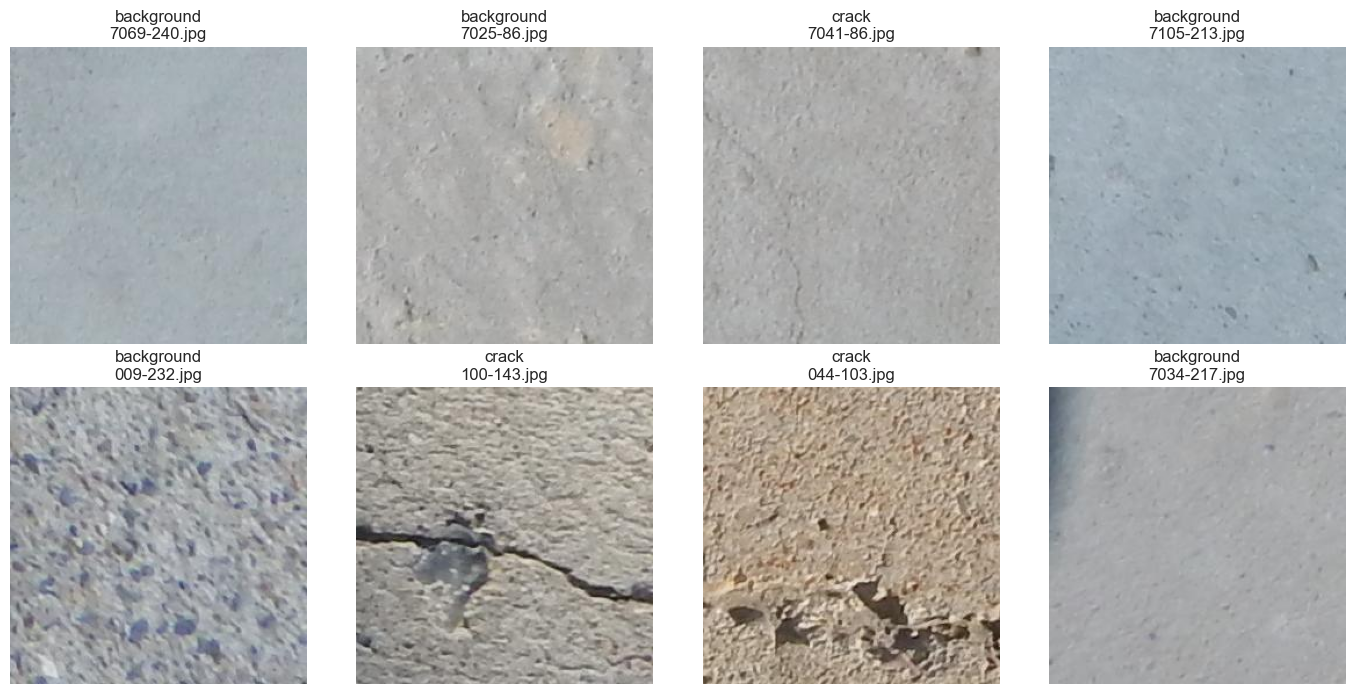

In [5]:
def visualize_segmentation_pairs(split_pairs: Sequence[Tuple[Path, Path]], split_name: str, n_samples: int = 4) -> None:
    sample_count = min(n_samples, len(split_pairs))
    sampled_pairs = random.sample(list(split_pairs), k=sample_count)
    fig, axes = plt.subplots(sample_count, 3, figsize=(14, 4 * sample_count))
    if sample_count == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_idx, (image_path, mask_path) in enumerate(sampled_pairs):
        image = load_image_rgb(image_path)
        mask = load_mask_binary(mask_path)
        overlay = image.copy()
        overlay[mask == 1] = [255, 80, 80]
        axes[row_idx, 0].imshow(image)
        axes[row_idx, 0].set_title(image_path.name)
        axes[row_idx, 1].imshow(mask, cmap='gray')
        axes[row_idx, 1].set_title(mask_path.name)
        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title('Overlay')
        for col_idx in range(3):
            axes[row_idx, col_idx].axis('off')
    plt.tight_layout()
    plt.show()

def visualize_classification_samples(samples: Sequence[Tuple[Path, int]], n_samples: int = 8) -> None:
    sample_count = min(n_samples, len(samples))
    chosen = random.sample(list(samples), k=sample_count)
    cols = 4
    rows = math.ceil(sample_count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.ravel():
        ax.axis('off')
    for idx, (image_path, label) in enumerate(chosen):
        image = load_image_rgb(image_path)
        ax = axes.ravel()[idx]
        ax.imshow(image)
        ax.set_title(f"{'crack' if label == 1 else 'background'}\n{image_path.name}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

if DATA_READY:
    if TASK_MODE == 'segmentation':
        visualize_segmentation_pairs(DATASET_INFO['split_pairs']['train'], 'train', n_samples=4)
    elif TASK_MODE == 'classification':
        visualize_classification_samples(DATASET_INFO['classification_samples'], n_samples=8)
else:
    print('No visualizations because the dataset is not ready.')


## Albumentations Transforms

Train-time augmentation improves robustness, while validation and test transforms standardize inputs.


In [6]:
def build_transforms(train: bool) -> A.Compose:
    if TASK_MODE == 'segmentation':
        height, width = CFG.segmentation_input_height, CFG.segmentation_input_width
    else:
        height, width = CFG.classification_input_height, CFG.classification_input_width
    resize = [A.Resize(height=height, width=width)]
    aug = [A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.2), A.RandomRotate90(p=0.3), A.RandomBrightnessContrast(p=0.2)] if train else []
    return A.Compose(resize + aug + [A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2(transpose_mask=True)])

TRAIN_TRANSFORMS = build_transforms(train=True)
EVAL_TRANSFORMS = build_transforms(train=False)


## Dataset And DataLoader Classes

The notebook defines task-specific dataset classes and creates loaders for the active mode.


In [7]:
class SegmentationDataset(Dataset):
    def __init__(self, pairs: Sequence[Tuple[Path, Path]], transforms: Optional[A.Compose] = None):
        self.samples = list(pairs)
        self.transforms = transforms
    def __len__(self) -> int:
        return len(self.samples)
    def __getitem__(self, index: int) -> Dict[str, object]:
        image_path, mask_path = self.samples[index]
        image = load_image_rgb(image_path)
        mask = load_mask_binary(mask_path)
        transformed = self.transforms(image=image, mask=mask) if self.transforms is not None else {'image': torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0, 'mask': torch.from_numpy(mask)}
        image_tensor = transformed['image']
        mask_tensor = transformed['mask']
        if mask_tensor.ndim == 2:
            mask_tensor = mask_tensor.unsqueeze(0)
        return {'image': image_tensor, 'target': mask_tensor.float(), 'image_path': str(image_path)}

class ClassificationDataset(Dataset):
    def __init__(self, samples: Sequence[Tuple[Path, int]], transforms: Optional[A.Compose] = None):
        self.samples = list(samples)
        self.transforms = transforms
    def __len__(self) -> int:
        return len(self.samples)
    def __getitem__(self, index: int) -> Dict[str, object]:
        image_path, label = self.samples[index]
        image = load_image_rgb(image_path)
        transformed = self.transforms(image=image)
        return {'image': transformed['image'], 'target': torch.tensor(label, dtype=torch.long), 'image_path': str(image_path)}

def create_dataloader(dataset: Dataset, shuffle: bool) -> DataLoader:
    worker_count = CFG.num_workers if len(dataset) > 0 else 0
    dataloader_kwargs = {
        'dataset': dataset,
        'batch_size': CFG.batch_size,
        'shuffle': shuffle,
        'num_workers': worker_count,
        'pin_memory': CFG.pin_memory and torch.cuda.is_available(),
        'persistent_workers': CFG.persistent_workers and worker_count > 0,
        'worker_init_fn': seed_worker if worker_count > 0 else None,
        'generator': TORCH_GENERATOR,
    }
    if worker_count > 0:
        dataloader_kwargs['prefetch_factor'] = 2
    return DataLoader(**dataloader_kwargs)

def build_classification_splits(samples: Sequence[Tuple[Path, int]]) -> Dict[str, List[Tuple[Path, int]]]:
    paths = np.array([str(path) for path, _ in samples])
    labels = np.array([label for _, label in samples])
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(paths, labels, test_size=CFG.val_fraction + CFG.test_fraction, random_state=CFG.seed, stratify=labels)
    relative_test_size = CFG.test_fraction / (CFG.val_fraction + CFG.test_fraction)
    val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=relative_test_size, random_state=CFG.seed, stratify=temp_labels)
    return {
        'train': [(Path(path), int(label)) for path, label in zip(train_paths.tolist(), train_labels.tolist())],
        'val': [(Path(path), int(label)) for path, label in zip(val_paths.tolist(), val_labels.tolist())],
        'test': [(Path(path), int(label)) for path, label in zip(test_paths.tolist(), test_labels.tolist())],
    }

if DATA_READY and TASK_MODE == 'segmentation':
    train_dataset = SegmentationDataset(DATASET_INFO['split_pairs']['train'], transforms=TRAIN_TRANSFORMS)
    val_dataset = SegmentationDataset(DATASET_INFO['split_pairs']['val'], transforms=EVAL_TRANSFORMS)
    test_dataset = SegmentationDataset(DATASET_INFO['split_pairs']['test'], transforms=EVAL_TRANSFORMS)
elif DATA_READY and TASK_MODE == 'classification':
    CLASS_SPLITS = build_classification_splits(DATASET_INFO['classification_samples'])
    split_summary = pd.DataFrame([{'split': split, 'samples': len(items), 'positive_rate': np.mean([label for _, label in items])} for split, items in CLASS_SPLITS.items()])
    display(split_summary)
    train_dataset = ClassificationDataset(CLASS_SPLITS['train'], transforms=TRAIN_TRANSFORMS)
    val_dataset = ClassificationDataset(CLASS_SPLITS['val'], transforms=EVAL_TRANSFORMS)
    test_dataset = ClassificationDataset(CLASS_SPLITS['test'], transforms=EVAL_TRANSFORMS)
else:
    train_dataset = val_dataset = test_dataset = None

if train_dataset is not None:
    train_loader = create_dataloader(train_dataset, shuffle=True)
    val_loader = create_dataloader(val_dataset, shuffle=False)
    test_loader = create_dataloader(test_dataset, shuffle=False)
    print(f'Train samples: {len(train_dataset)}')
    print(f'Val samples: {len(val_dataset)}')
    print(f'Test samples: {len(test_dataset)}')
else:
    train_loader = val_loader = test_loader = None


,split,samples,positive_rate
0,train,44873,0.151249
1,val,5609,0.151186
2,test,5610,0.151337


Train samples: 44873
Val samples: 5609
Test samples: 5610


## Exploratory Visualisation

This section shows representative segmentation pairs or classification samples from the active task mode.


In [8]:
EPSILON = 1e-7

def threshold_logits(logits: torch.Tensor, threshold: float = CFG.threshold) -> torch.Tensor:
    return (torch.sigmoid(logits) >= threshold).float()

def segmentation_metrics_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> Dict[str, float]:
    preds = threshold_logits(logits)
    preds = preds.view(-1)
    targets = targets.float().view(-1)
    tp = torch.sum(preds * targets).item()
    fp = torch.sum(preds * (1 - targets)).item()
    fn = torch.sum((1 - preds) * targets).item()
    dice = (2 * tp + EPSILON) / (2 * tp + fp + fn + EPSILON)
    iou = (tp + EPSILON) / (tp + fp + fn + EPSILON)
    precision = (tp + EPSILON) / (tp + fp + EPSILON)
    recall = (tp + EPSILON) / (tp + fn + EPSILON)
    f1 = (2 * precision * recall + EPSILON) / (precision + recall + EPSILON)
    return {'primary_metric': dice, 'dice': dice, 'iou': iou, 'precision': precision, 'recall': recall, 'f1': f1}

def classification_metrics_from_predictions(y_true: List[int], y_pred: List[int]) -> Dict[str, float]:
    return {
        'primary_metric': f1_score(y_true, y_pred, zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }


## Loss Functions

Segmentation uses BCE plus Dice loss, while classification uses cross-entropy.


In [9]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits).view(logits.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)
        dice_loss = 1 - ((2 * intersection + EPSILON) / (denominator + EPSILON)).mean()
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

SEGMENTATION_CRITERION = BCEDiceLoss()
CLASSIFICATION_CRITERION = nn.CrossEntropyLoss()


## Model Factory

The model factory builds task-appropriate baseline models under a shared interface.


In [10]:
def build_segmentation_model(model_name: str, architecture: str, encoder_name: str) -> nn.Module:
    if smp is None:
        raise ImportError('segmentation_models_pytorch is required for segmentation mode.')
    if architecture == 'unet':
        return smp.Unet(encoder_name=encoder_name, encoder_weights='imagenet', in_channels=3, classes=1)
    if architecture == 'deeplabv3plus':
        return smp.DeepLabV3Plus(encoder_name=encoder_name, encoder_weights='imagenet', in_channels=3, classes=1)
    raise ValueError(f'Unsupported segmentation architecture: {architecture}')

def build_classification_model(model_name: str, architecture: str) -> nn.Module:
    if architecture == 'resnet18':
        weights = torchvision.models.ResNet18_Weights.DEFAULT
        model = torchvision.models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, 2)
        return model
    if architecture == 'efficientnet_b0':
        weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
        model = torchvision.models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
        return model
    raise ValueError(f'Unsupported classification architecture: {architecture}')

def active_model_definitions() -> Tuple[Tuple[str, Dict[str, str]], ...]:
    return CFG.segmentation_models if TASK_MODE == 'segmentation' else CFG.classification_models


## Training And Validation Loops

The training code handles both task modes, uses mixed precision on CUDA, tracks the primary validation metric, and saves the best checkpoint.


In [11]:
def train_or_validate_epoch(model: nn.Module, dataloader: DataLoader, optimizer: Optional[torch.optim.Optimizer], stage: str) -> Dict[str, float]:
    is_train = optimizer is not None
    model.train(is_train)
    scaler = torch.amp.GradScaler('cuda', enabled=Config.USE_AMP and is_train) if torch.cuda.is_available() else torch.amp.GradScaler('cpu', enabled=False)
    total_loss = 0.0
    total_samples = 0
    total_primary = 0.0
    cls_targets: List[int] = []
    cls_preds: List[int] = []
    progress = tqdm(dataloader, desc=stage, leave=False)
    for batch in progress:
        images = batch['image'].to(Config.device, non_blocking=True)
        targets = batch['target'].to(Config.device, non_blocking=True)
        batch_size = images.size(0)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type=Config.device.type, enabled=Config.USE_AMP| is_train):
                logits = model(images)
                if TASK_MODE == 'segmentation':
                    loss = SEGMENTATION_CRITERION(logits, targets)
                else:
                    loss = CLASSIFICATION_CRITERION(logits, targets)
            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        if TASK_MODE == 'segmentation':
            batch_metrics = segmentation_metrics_from_logits(logits.detach(), targets.detach())
            total_primary += batch_metrics['primary_metric'] * batch_size
            progress.set_postfix(loss=f"{loss.item():.4f}", metric=f"{batch_metrics['primary_metric']:.4f}")
        else:
            preds = torch.argmax(logits.detach(), dim=1)
            cls_targets.extend(targets.detach().cpu().numpy().tolist())
            cls_preds.extend(preds.cpu().numpy().tolist())
            progress.set_postfix(loss=f"{loss.item():.4f}")
    metrics = {'loss': total_loss / max(total_samples, 1)}
    if TASK_MODE == 'segmentation':
        metrics['primary_metric'] = total_primary / max(total_samples, 1)
    else:
        cls_metrics = classification_metrics_from_predictions(cls_targets, cls_preds)
        metrics.update(cls_metrics)
    return metrics

def describe_model(model: nn.Module) -> None:
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
    print('Model structure:')
    print(model)
    print(f'Total parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')

def train_model(model_name: str, spec: Dict[str, str]) -> Dict[str, object]:
    if TASK_MODE == 'segmentation':
        model = build_segmentation_model(model_name, spec['architecture'], spec['encoder_name']).to(Config.device)
    else:
        model = build_classification_model(model_name, spec['architecture']).to(Config.device)
    describe_model(model)
    optimizer = AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    best_metric = -math.inf
    no_improve = 0
    history_rows: List[Dict[str, float]] = []
    checkpoint_path = Path(CFG.checkpoints_dir) / f'{TASK_MODE}_{model_name}_best.pt'
    start_time = time.time()
    epoch_progress = tqdm(range(1, CFG.epochs + 1), desc=f'{model_name} epochs', leave=False)
    for epoch in epoch_progress:
        train_metrics = train_or_validate_epoch(model, train_loader, optimizer, f'{model_name} train {epoch}/{CFG.epochs}')
        val_metrics = train_or_validate_epoch(model, val_loader, None, f'{model_name} val {epoch}/{CFG.epochs}')
        scheduler.step(val_metrics['loss'])
        history_rows.append({'epoch': epoch, 'train_loss': train_metrics['loss'], 'val_loss': val_metrics['loss'], 'train_metric': train_metrics['primary_metric'], 'val_metric': val_metrics['primary_metric'], 'learning_rate': optimizer.param_groups[0]['lr']})
        best_so_far = max(best_metric, val_metrics['primary_metric'])
        epoch_progress.set_postfix(best=f'{best_so_far:.4f}', val=f"{val_metrics['primary_metric']:.4f}")
        print(f"Epoch {epoch:02d} | train_loss={train_metrics['loss']:.4f} | train_metric={train_metrics['primary_metric']:.4f} | val_loss={val_metrics['loss']:.4f} | val_metric={val_metrics['primary_metric']:.4f}")
        if val_metrics['primary_metric'] > best_metric:
            best_metric = val_metrics['primary_metric']
            no_improve = 0
            torch.save({'model_name': model_name, 'task_mode': TASK_MODE, 'spec': spec, 'state_dict': model.state_dict(), 'epoch': epoch, 'best_val_metric': best_metric, 'config': asdict(CFG)}, checkpoint_path)
        else:
            no_improve += 1
        if no_improve >= CFG.patience:
            print(f'Early stopping triggered for {model_name}.')
            break
    history_df = pd.DataFrame(history_rows)
    history_path = Path(CFG.metrics_dir) / f'{TASK_MODE}_{model_name}_history.csv'
    history_df.to_csv(history_path, index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
    axes[0].set_title(f'{model_name} loss')
    axes[0].legend()
    axes[1].plot(history_df['epoch'], history_df['train_metric'], label='train')
    axes[1].plot(history_df['epoch'], history_df['val_metric'], label='val')
    axes[1].set_title(f'{model_name} primary metric')
    axes[1].legend()
    plt.tight_layout()
    plot_path = Path(CFG.plots_dir) / f'{TASK_MODE}_{model_name}_training_curves.png'
    plt.savefig(plot_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    minutes = (time.time() - start_time) / 60.0
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {'model_name': model_name, 'best_checkpoint_path': str(checkpoint_path), 'best_val_metric': best_metric, 'epochs_ran': int(history_df['epoch'].max()) if not history_df.empty else 0, 'train_minutes': minutes, 'history_path': str(history_path), 'plot_path': str(plot_path)}


## Train All Models

Each model is trained under the same optimizer, scheduler, augmentation, and stopping setup for the active task mode.



Starting training for resnet18 in classification mode
Model structure:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

resnet18 epochs:   0%|          | 0/1 [00:00<?, ?it/s]

resnet18 train 1/1:   0%|          | 0/2805 [00:00<?, ?it/s]

resnet18 val 1/1:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2419 | train_metric=0.6638 | val_loss=0.1872 | val_metric=0.7477


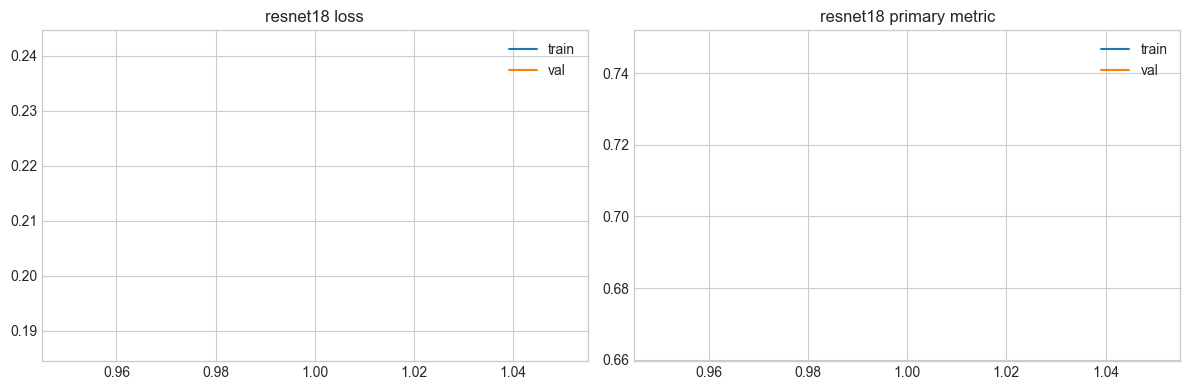


Starting training for efficientnet_b0 in classification mode
Model structure:
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
       

efficientnet_b0 epochs:   0%|          | 0/1 [00:00<?, ?it/s]

efficientnet_b0 train 1/1:   0%|          | 0/2805 [00:00<?, ?it/s]

efficientnet_b0 val 1/1:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2368 | train_metric=0.6880 | val_loss=0.1800 | val_metric=0.7838


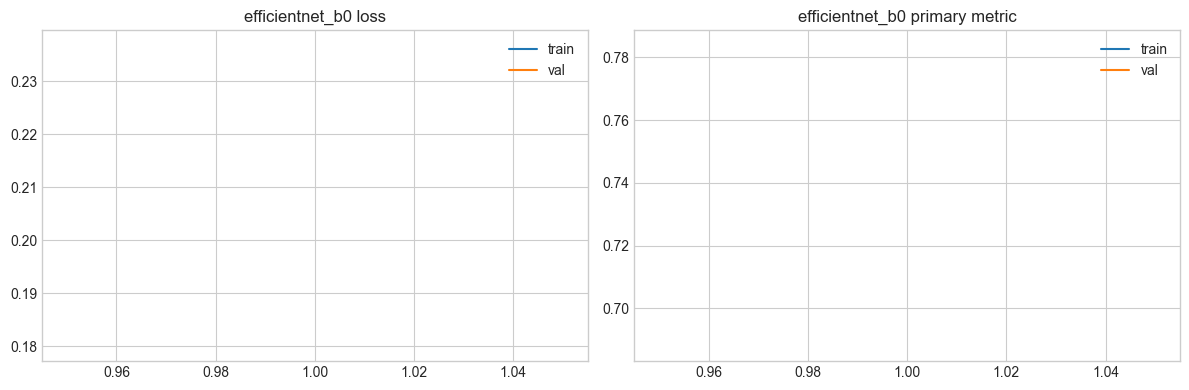

,model_name,best_checkpoint_path,best_val_metric,epochs_ran,train_minutes,history_path,plot_path
0,resnet18,artifacts\checkpoints\classification_resnet18_best.pt,0.747729,1,3.589221,artifacts\metrics\classification_resnet18_history.csv,artifacts\plots\classification_resnet18_training_curves.png
1,efficientnet_b0,artifacts\checkpoints\classification_efficientnet_b0_best.pt,0.783818,1,6.205418,artifacts\metrics\classification_efficientnet_b0_history.csv,artifacts\plots\classification_efficientnet_b0_training_curves.png


In [12]:
TRAINING_SUMMARIES: List[Dict[str, object]] = []
if DATA_READY and train_loader is not None:
    for model_name, spec in active_model_definitions():
        print(f'\nStarting training for {model_name} in {TASK_MODE} mode')
        TRAINING_SUMMARIES.append(train_model(model_name, spec))
    TRAINING_SUMMARIES_DF = pd.DataFrame(TRAINING_SUMMARIES)
    display(TRAINING_SUMMARIES_DF)
else:
    TRAINING_SUMMARIES_DF = pd.DataFrame()
    print('Skipping training because the dataset is not ready.')


## Test Evaluation And Prediction Visualization

This section reloads each best checkpoint, evaluates on the test split, and saves qualitative examples.


resnet18 test:   0%|          | 0/351 [00:00<?, ?it/s]

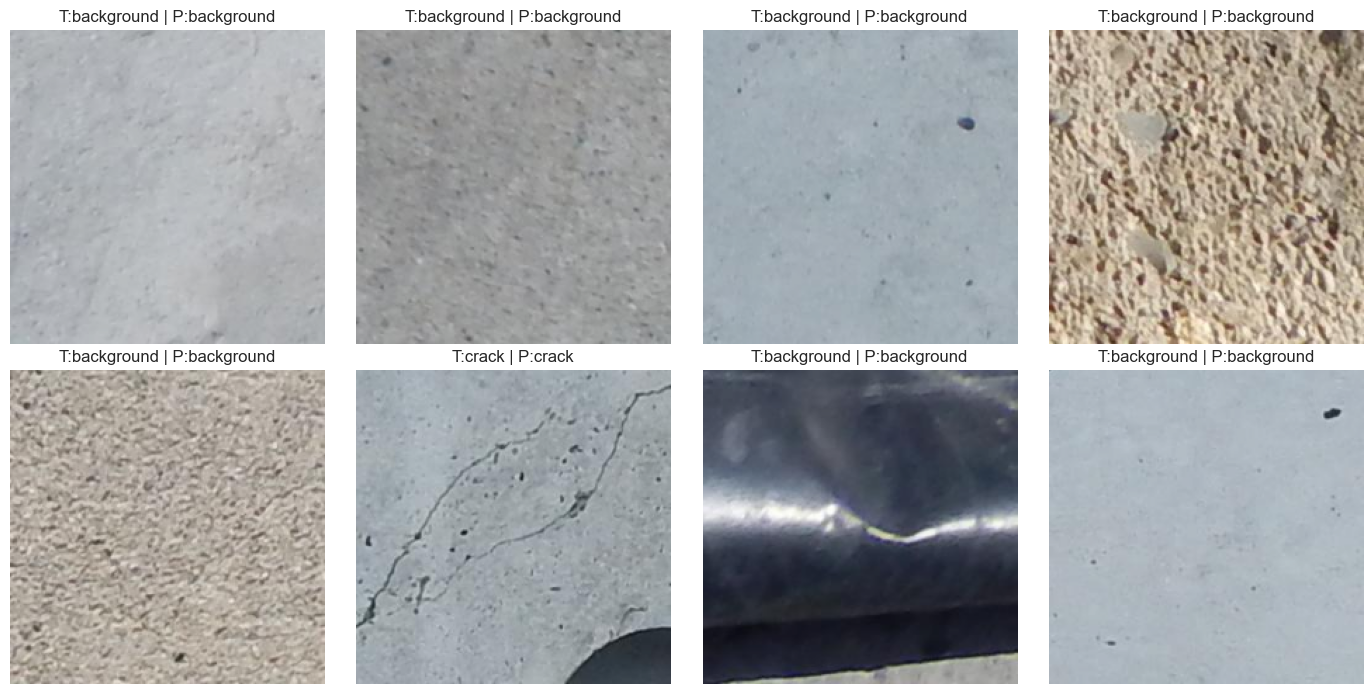

efficientnet_b0 test:   0%|          | 0/351 [00:00<?, ?it/s]

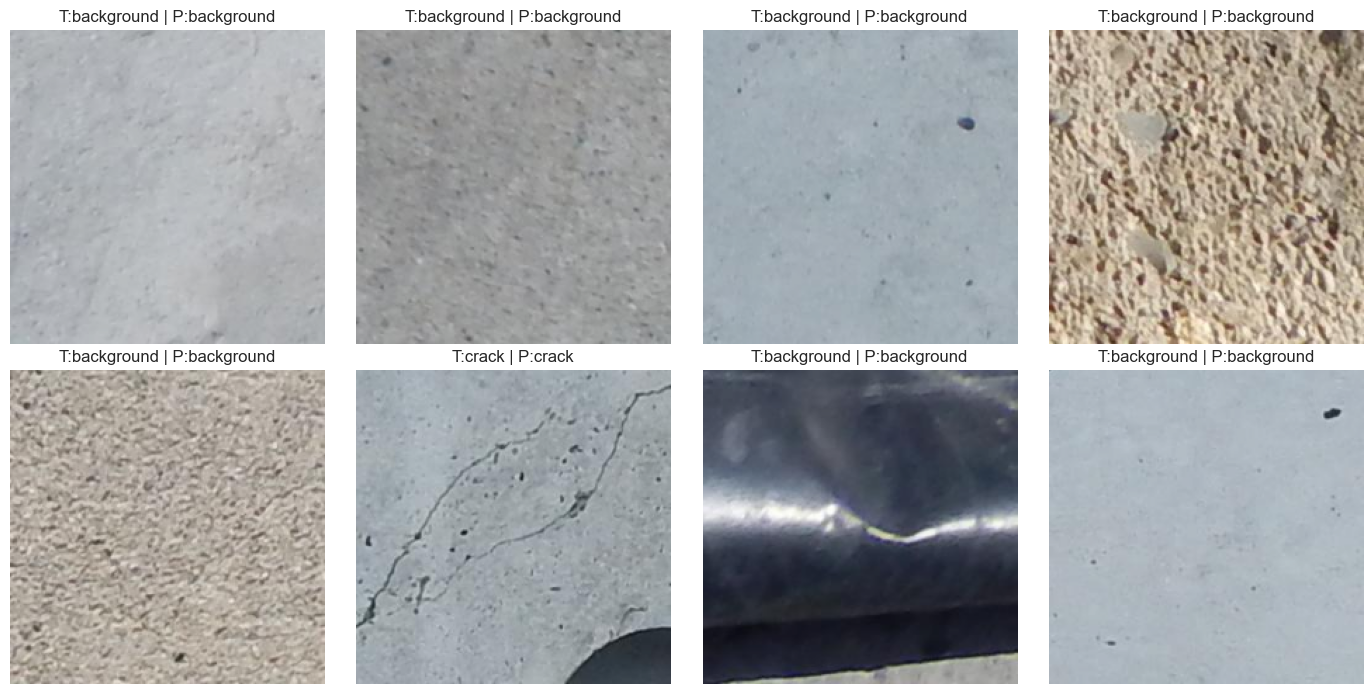

,test_loss,primary_metric,accuracy,precision,recall,f1,prediction_plot_path,metrics_json_path,model_name,task_mode
0,0.172902,0.764261,0.938859,0.917492,0.654888,0.764261,artifacts\plots\classification_resnet18_test_predictions.png,artifacts\metrics\classification_resnet18_test_metrics.json,resnet18,classification
1,0.172838,0.784363,0.939037,0.843962,0.732627,0.784363,artifacts\plots\classification_efficientnet_b0_test_predictions.png,artifacts\metrics\classification_efficientnet_b0_test_metrics.json,efficientnet_b0,classification


In [14]:
def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    image = image_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    return (image * std + mean).clip(0, 1)

def evaluate_model(model_name: str, spec: Dict[str, str], checkpoint_path: str) -> Dict[str, object]:
    checkpoint = torch.load(checkpoint_path, map_location=Config.device)
    model = build_segmentation_model(model_name, spec['architecture'], spec['encoder_name']).to(Config.device) if TASK_MODE == 'segmentation' else build_classification_model(model_name, spec['architecture']).to(Config.device)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    total_loss = 0.0
    total_samples = 0
    seg_metrics_accum = {'dice': 0.0, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
    cls_targets: List[int] = []
    cls_preds: List[int] = []
    visual_items: List[Dict[str, object]] = []
    with torch.no_grad():
        progress = tqdm(test_loader, desc=f'{model_name} test', leave=False)
        for batch in progress:
            images = batch['image'].to(Config.device, non_blocking=True)
            targets = batch['target'].to(Config.device, non_blocking=True)
            batch_size = images.size(0)
            with torch.autocast(device_type=Config.device.type, enabled=CFG.USE_AMP):
                logits = model(images)
                loss = SEGMENTATION_CRITERION(logits, targets) if TASK_MODE == 'segmentation' else CLASSIFICATION_CRITERION(logits, targets)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            if TASK_MODE == 'segmentation':
                metrics = segmentation_metrics_from_logits(logits, targets)
                for key in seg_metrics_accum:
                    seg_metrics_accum[key] += metrics[key] * batch_size
                probs = torch.sigmoid(logits)
                preds = (probs >= CFG.threshold).float()
                for sample_idx in range(batch_size):
                    if len(visual_items) >= CFG.max_visualizations_per_model:
                        break
                    visual_items.append({'image': denormalize_image(images[sample_idx]), 'target': targets[sample_idx, 0].detach().cpu().numpy(), 'prediction': preds[sample_idx, 0].detach().cpu().numpy(), 'probability': probs[sample_idx, 0].detach().cpu().numpy(), 'image_path': batch['image_path'][sample_idx]})
            else:
                preds = torch.argmax(logits, dim=1)
                cls_targets.extend(targets.cpu().numpy().tolist())
                cls_preds.extend(preds.cpu().numpy().tolist())
                for sample_idx in range(batch_size):
                    if len(visual_items) >= CFG.max_visualizations_per_model:
                        break
                    visual_items.append({'image': denormalize_image(images[sample_idx]), 'target': int(targets[sample_idx].item()), 'prediction': int(preds[sample_idx].item()), 'image_path': batch['image_path'][sample_idx]})
    results = {'test_loss': total_loss / max(total_samples, 1)}
    if TASK_MODE == 'segmentation':
        for key, value in seg_metrics_accum.items():
            results[key] = value / max(total_samples, 1)
        results['primary_metric'] = results['dice']
        fig, axes = plt.subplots(len(visual_items), 4, figsize=(16, 4 * len(visual_items)))
        if len(visual_items) == 1:
            axes = np.expand_dims(axes, axis=0)
        for row_idx, item in enumerate(visual_items):
            overlay = item['image'].copy()
            overlay[item['prediction'] >= 0.5] = [1.0, 0.25, 0.25]
            axes[row_idx, 0].imshow(item['image'])
            axes[row_idx, 0].set_title(Path(item['image_path']).name)
            axes[row_idx, 1].imshow(item['target'], cmap='gray')
            axes[row_idx, 1].set_title('Ground truth')
            axes[row_idx, 2].imshow(item['probability'], cmap='magma', vmin=0, vmax=1)
            axes[row_idx, 2].set_title('Predicted probability')
            axes[row_idx, 3].imshow(overlay)
            axes[row_idx, 3].set_title('Overlay')
            for col_idx in range(4):
                axes[row_idx, col_idx].axis('off')
    else:
        cls_metrics = classification_metrics_from_predictions(cls_targets, cls_preds)
        results.update(cls_metrics)
        fig, axes = plt.subplots(math.ceil(len(visual_items) / 4), 4, figsize=(14, 3.5 * math.ceil(len(visual_items) / 4)))
        axes = np.array(axes).reshape(-1, 4)
        for ax in axes.ravel():
            ax.axis('off')
        for idx, item in enumerate(visual_items):
            ax = axes.ravel()[idx]
            ax.imshow(item['image'])
            target_name = 'crack' if item['target'] == 1 else 'background'
            pred_name = 'crack' if item['prediction'] == 1 else 'background'
            ax.set_title(f'T:{target_name} | P:{pred_name}')
            ax.axis('off')
    plt.tight_layout()
    plot_path = Path(CFG.plots_dir) / f'{TASK_MODE}_{model_name}_test_predictions.png'
    plt.savefig(plot_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    results['prediction_plot_path'] = str(plot_path)
    metrics_path = Path(CFG.metrics_dir) / f'{TASK_MODE}_{model_name}_test_metrics.json'
    with open(metrics_path, 'w', encoding='utf-8') as file:
        json.dump(results, file, indent=2)
    results['metrics_json_path'] = str(metrics_path)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return results

EVALUATION_SUMMARIES: List[Dict[str, object]] = []
if DATA_READY and not TRAINING_SUMMARIES_DF.empty:
    for model_name, spec in active_model_definitions():
        checkpoint_path = TRAINING_SUMMARIES_DF.loc[TRAINING_SUMMARIES_DF['model_name'] == model_name, 'best_checkpoint_path'].iloc[0]
        result = evaluate_model(model_name, spec, checkpoint_path)
        result['model_name'] = model_name
        result['task_mode'] = TASK_MODE
        EVALUATION_SUMMARIES.append(result)
    EVALUATION_SUMMARIES_DF = pd.DataFrame(EVALUATION_SUMMARIES)
    display(EVALUATION_SUMMARIES_DF)
else:
    EVALUATION_SUMMARIES_DF = pd.DataFrame()
    print('Skipping evaluation because training results are not available.')


## Results Comparison DataFrame

This table consolidates training and test performance into one benchmark view with one row per model.


In [15]:
if not TRAINING_SUMMARIES_DF.empty and not EVALUATION_SUMMARIES_DF.empty:
    RESULTS_DF = EVALUATION_SUMMARIES_DF.merge(TRAINING_SUMMARIES_DF[['model_name', 'best_val_metric', 'epochs_ran', 'train_minutes']], on='model_name', how='left')
    RESULTS_DF = RESULTS_DF.sort_values(by='primary_metric', ascending=False).reset_index(drop=True)
    display(RESULTS_DF)
else:
    RESULTS_DF = pd.DataFrame()
    print('Benchmark table will populate after training and evaluation complete.')


,test_loss,primary_metric,accuracy,precision,recall,f1,prediction_plot_path,metrics_json_path,model_name,task_mode,best_val_metric,epochs_ran,train_minutes
0,0.172838,0.784363,0.939037,0.843962,0.732627,0.784363,artifacts\plots\classification_efficientnet_b0_test_predictions.png,artifacts\metrics\classification_efficientnet_b0_test_metrics.json,efficientnet_b0,classification,0.783818,1,6.205418
1,0.172902,0.764261,0.938859,0.917492,0.654888,0.764261,artifacts\plots\classification_resnet18_test_predictions.png,artifacts\metrics\classification_resnet18_test_metrics.json,resnet18,classification,0.747729,1,3.589221


## Save Summary CSV And JSON

The benchmark comparison is exported for downstream reporting and reproducible experiment tracking.


In [16]:
BENCHMARK_CSV_PATH = Path(CFG.metrics_dir) / f'{TASK_MODE}_benchmark_summary.csv'
BENCHMARK_JSON_PATH = Path(CFG.metrics_dir) / f'{TASK_MODE}_benchmark_summary.json'
if not RESULTS_DF.empty:
    RESULTS_DF.to_csv(BENCHMARK_CSV_PATH, index=False)
    with open(BENCHMARK_JSON_PATH, 'w', encoding='utf-8') as file:
        json.dump(RESULTS_DF.to_dict(orient='records'), file, indent=2)
    print(f'Saved CSV summary to: {BENCHMARK_CSV_PATH}')
    print(f'Saved JSON summary to: {BENCHMARK_JSON_PATH}')
else:
    print('No benchmark summary saved because the results table is empty.')


Saved CSV summary to: artifacts\metrics\classification_benchmark_summary.csv
Saved JSON summary to: artifacts\metrics\classification_benchmark_summary.json
